In [4]:
import numpy as np
import matplotlib.pyplot as plt

tree_position = [1,1]
sensor_position = [2,2]

dx = sensor_position[0] - tree_position[0]
dy = sensor_position[1] - tree_position[1]
d = np.sqrt(dx**2 + dy**2)
print(f"Distance from sensor to tree: {d}")

Distance from sensor to tree: 1.4142135623730951


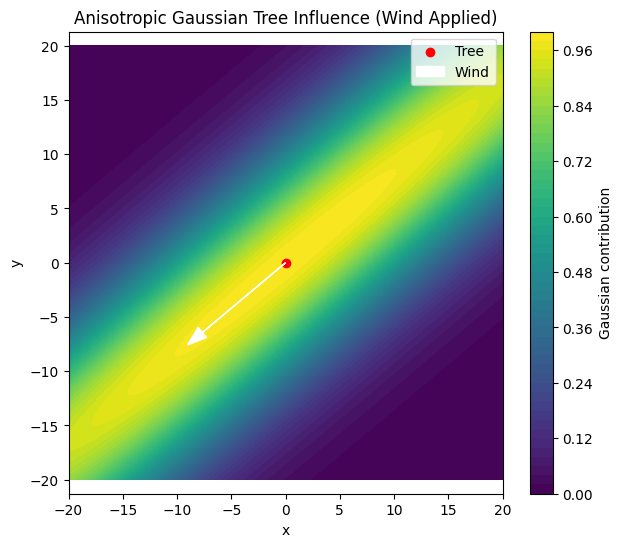

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Grid around the tree ---
x = np.linspace(-20, 20, 200)
y = np.linspace(-20, 20, 200)
X, Y = np.meshgrid(x, y)

# --- Wind direction (same as your setup) ---
wind_speed = 10
wind_from = 50
wind_to = (wind_from + 180) % 360

theta = np.deg2rad(90 - wind_to)
wx = np.cos(theta)
wy = np.sin(theta)

# --- Rotate coordinates into wind frame ---
X_parallel = X * wx + Y * wy
X_perp = -X * wy + Y * wx

# --- Parameters ---
R = 6
k = 0.1

sigma_parallel = R * (1 + k * wind_speed**2)
sigma_perp = R

# --- Gaussian field ---
G = np.exp(
    - (X_parallel**2) / (2 * sigma_parallel**2)
    - (X_perp**2) / (2 * sigma_perp**2)
)

# --- Plot ---
plt.figure(figsize=(7,6))
plt.contourf(X, Y, G, levels=50)
plt.colorbar(label="Gaussian contribution")

# Tree at origin
plt.scatter(0, 0, color='red', label='Tree')

# Wind direction arrow
plt.arrow(0, 0, wx*10, wy*10, color='white', head_width=1.2, label='Wind')

plt.title("Anisotropic Gaussian Tree Influence (Wind Applied)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axis("equal")
plt.show()

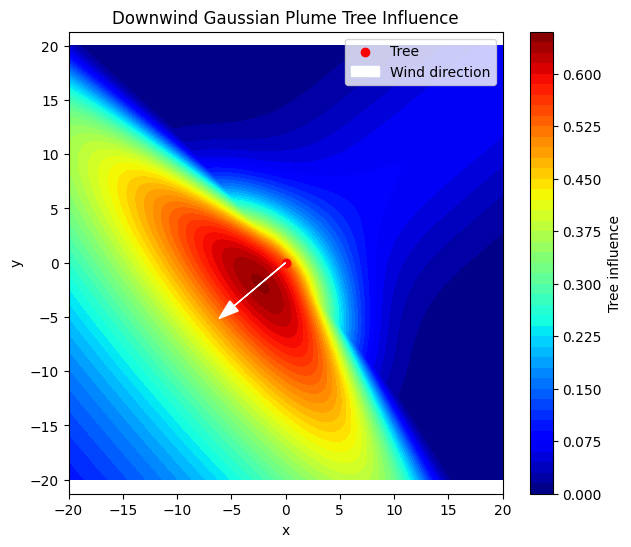

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# --- Grid around the tree ---
x = np.linspace(-20, 20, 200)
y = np.linspace(-20, 20, 200)
X, Y = np.meshgrid(x, y)

# --- Tree position ---
tree_x = 0
tree_y = 0

# --- Wind setup ---
wind_speed = 25
wind_from = 50
wind_to = (wind_from + 180) % 360

theta = np.deg2rad(90 - wind_to)
wx = np.cos(theta)
wy = np.sin(theta)

# --- Coordinates relative to the tree ---
dx = X - tree_x
dy = Y - tree_y

# Distance along wind direction
X_parallel = dx * wx + dy * wy

# Distance perpendicular to wind direction
X_perp = -dx * wy + dy * wx

# --- Initial parameters ---
R = 6
k = 0.1

if wind_speed == 0:
    # No wind: circular tree influence
    G = np.exp(
        - ((X - tree_x)**2 + (Y - tree_y)**2) / (2 * R**2)
    )

else:
    # Wind: downwind plume model
    ssigma_parallel = R * (1 + k * wind_speed**2)

    sigma_perp = R + k * wind_speed * np.maximum(X_parallel, 0)
    sigma_perp = np.maximum(sigma_perp, R)

    transition_strength = wind_speed / (wind_speed + 2)

    transition = (
        (1 - transition_strength)
        + transition_strength * (1 / (1 + np.exp(-X_parallel / 2)))
    )

    G = np.exp(
        - np.maximum(X_parallel, 0) / sigma_parallel
        - (X_perp**2) / (2 * sigma_perp**2)
    )

    G = G * transition 

# --- Plot ---
plt.figure(figsize=(7, 6))
plt.contourf(X, Y, G, levels=50, cmap="jet")
plt.colorbar(label="Tree influence")

plt.scatter(tree_x, tree_y, color="red", label="Tree")

plt.arrow(
    tree_x, tree_y,
    wx * 8, wy * 8,
    color="white",
    head_width=1.2,
    length_includes_head=True,
    label="Wind direction"
)

plt.title("Downwind Gaussian Plume Tree Influence")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axis("equal")
plt.show()